In [28]:
import kagglehub
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.


In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
import seaborn as sns
import cv2

In [30]:
TRAIN_DIR   = os.path.join(path, "Train")
TEST_DIR    = os.path.join(path, "Test")
TEST_CSV    = os.path.join(path, "Test.csv")

In [31]:
NUM_CLASSES = 43
CLASS_NAMES = {
    0:'Speed limit (20)',    1:'Speed limit (30)',   2:'Speed limit (50)',
    3:'Speed limit (60)',    4:'Speed limit (70)',   5:'Speed limit (80)',
    6:'End speed limit(80)', 7:'Speed limit (100)',  8:'Speed limit (120)',
    9:'No passing',         10:'No passing >3.5t',  11:'Right-of-way',
    12:'Priority road',     13:'Yield',              14:'Stop',
    15:'No vehicles',       16:'No >3.5t vehicles', 17:'No entry',
    18:'General caution',   19:'Danger curve left', 20:'Danger curve right',
    21:'Double curve',      22:'Bumpy road',         23:'Slippery road',
    24:'Road narrows',      25:'Road work',          26:'Traffic signals',
    27:'Pedestrians',       28:'Children crossing',  29:'Bicycles crossing',
    30:'Ice/snow',          31:'Wild animals',       32:'End speed+passing',
    33:'Turn right ahead',  34:'Turn left ahead',    35:'Ahead only',
    36:'Go straight/right', 37:'Go straight/left',   38:'Keep right',
    39:'Keep left',         40:'Roundabout',          41:'End no passing',
    42:'End no passing >3.5t'
}

In [32]:
print("Loading data from folder structure...")

train_paths = []
train_labels = []

# Loop through each class folder (0 to 42)
for class_id in tqdm(range(NUM_CLASSES), desc="Scanning class folders"):
    class_folder = os.path.join(TRAIN_DIR, str(class_id))
    if os.path.exists(class_folder):
        # Get all PNG files in the folder
        for img_file in os.listdir(class_folder):
            if img_file.endswith('.png'):
                img_path = os.path.join(class_folder, img_file)
                train_paths.append(img_path)
                train_labels.append(class_id)

print(f"\nTotal training images found: {len(train_paths):,}")

Loading data from folder structure...


Scanning class folders: 100%|██████████| 43/43 [00:00<00:00, 367.93it/s]


Total training images found: 39,209


In [33]:
# Check class distribution
class_counts = Counter(train_labels)
most_common = class_counts.most_common(1)[0]
least_common = min(class_counts.items(), key=lambda x: x[1])
print(f"Most common class     : {CLASS_NAMES[most_common[0]]} ({most_common[1]} imgs)")
print(f"Least common class    : {CLASS_NAMES[least_common[0]]} ({least_common[1]} imgs)")

Most common class     : Speed limit (50) (2250 imgs)
Least common class    : Speed limit (20) (210 imgs)


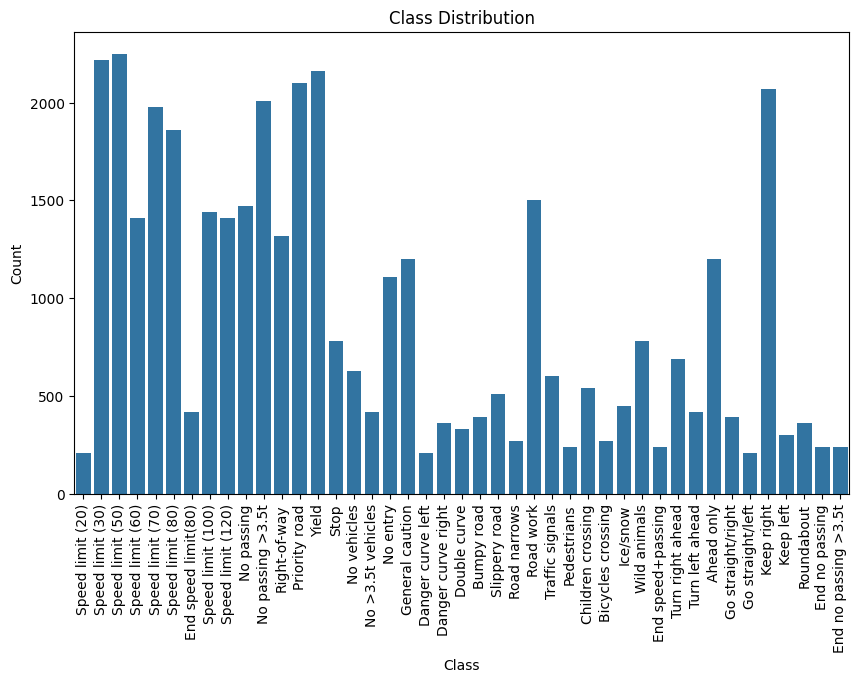

In [34]:
# visualize class balance
plt.figure(figsize=(10, 6))
sns.barplot(x=list(CLASS_NAMES.values()), y=list(class_counts.values()))
plt.xticks(rotation=90)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

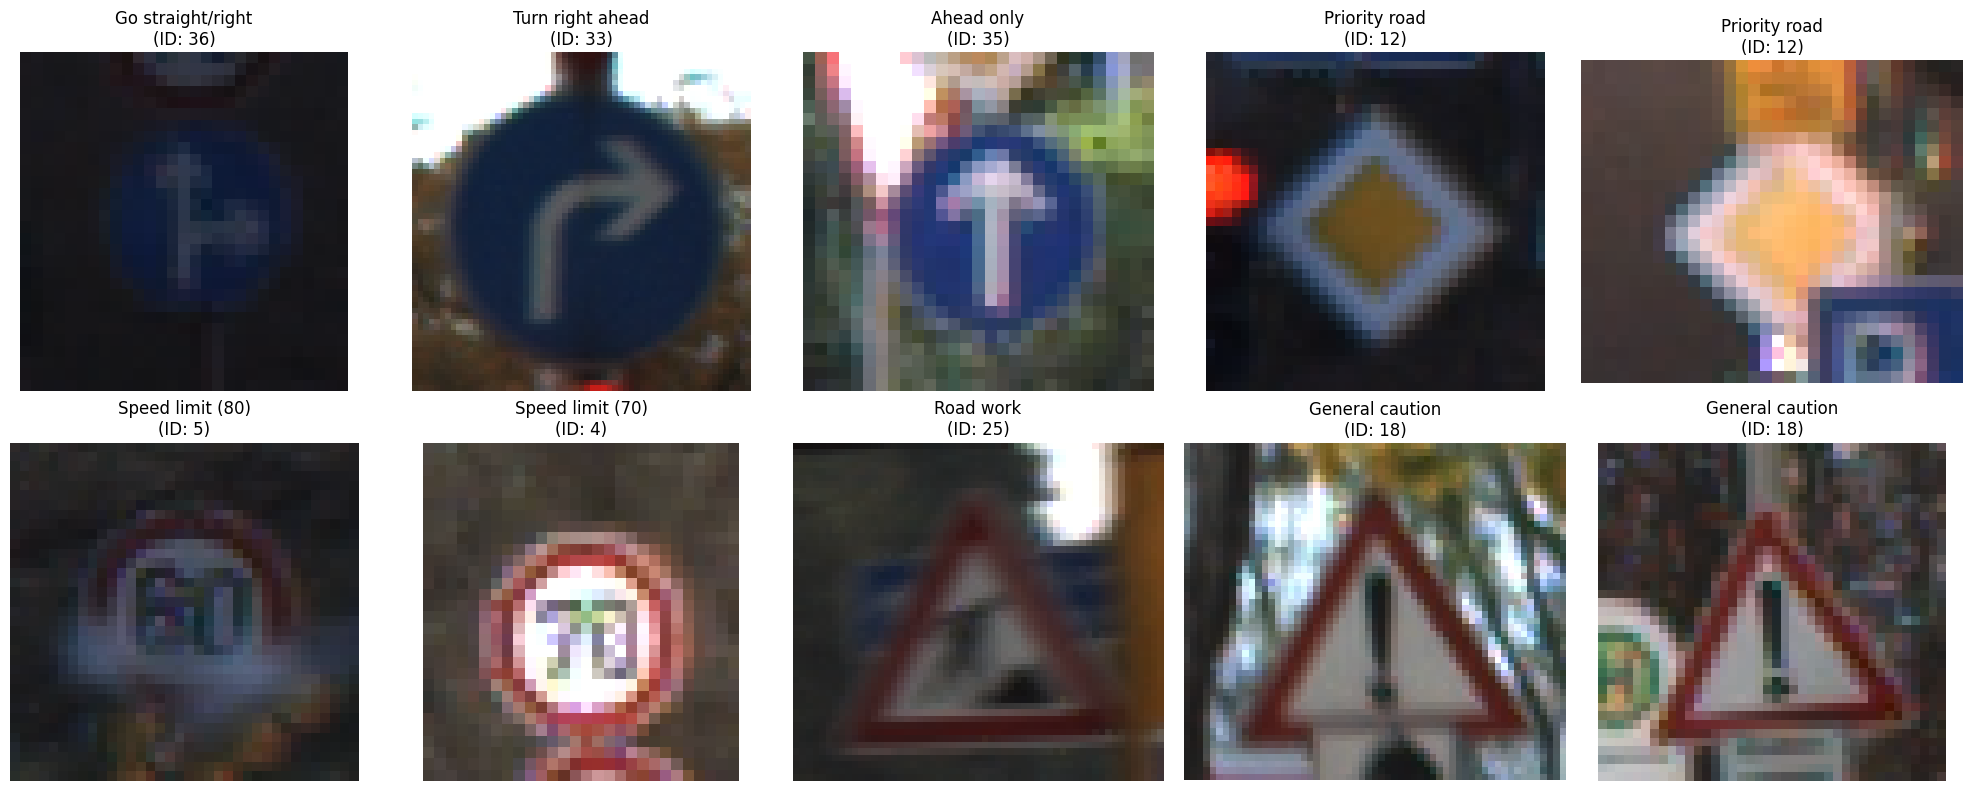

In [35]:
# show sample images
num_samples = 10
indices = np.random.choice(len(train_paths), num_samples, replace=False)

plt.figure(figsize=(20, 8))
for i, idx in enumerate(indices):
    img_path = train_paths[idx]
    label = train_labels[idx]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"{CLASS_NAMES[label]}\n(ID: {label})")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [36]:
# pixel statistics

# mean and std per channel (RGB)
sums = np.zeros(3)
sum_sqs = np.zeros(3)
pixel_count = 0

# swample for speed (every 2nd image)
for img_path in tqdm(train_paths[::2], desc="Processing the potato in images"):
    img = cv2.imread(img_path)
    if img is None: continue

    # Convert BGR (OpenCV default) to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Normalize to [0, 1]
    img = img.astype(np.float32) / 255.0

    sums += np.sum(img, axis=(0, 1))
    sum_sqs += np.sum(img**2, axis=(0, 1))
    pixel_count += img.shape[0] * img.shape[1]

mean = sums / pixel_count
std = np.sqrt((sum_sqs / pixel_count) - (mean**2))

print(f"\nDataset Statistics (RGB):")
print(f"Mean: {mean}")
print(f"Std:  {std}")

Processing the potato in images: 100%|██████████| 19605/19605 [00:29<00:00, 658.50it/s]


Dataset Statistics (RGB):
Mean: [0.38118964 0.35054421 0.35935626]
Std:  [0.30222234 0.29676159 0.30290229]


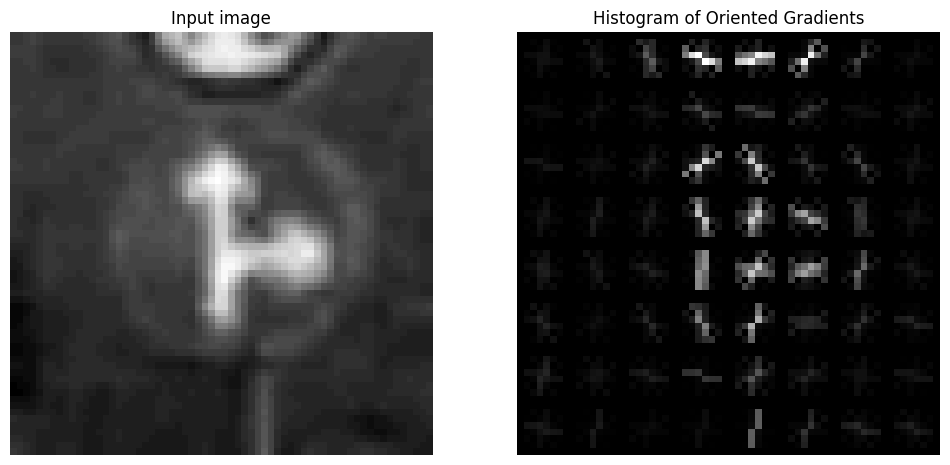

HOG feature vector shape: (512,)


In [37]:
from skimage.feature import hog
from skimage import exposure

# sample image to visualize HOG
img_path = train_paths[indices[0]]
img = cv2.imread(img_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_resized = cv2.resize(img_gray, (64, 64))

fd, hog_image = hog(img_resized, orientations=8, pixels_per_cell=(8, 8),
                    cells_per_block=(1, 1), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(img_resized, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

print(f'HOG feature vector shape: {fd.shape}')

In [40]:
def extract_hog(img_path):
    # Load and preprocess
    img = cv2.imread(img_path)
    if img is None: return None
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, (64, 64))

    # Extract HOG
    fd = hog(img_resized, orientations=8, pixels_per_cell=(8, 8),
             cells_per_block=(1, 1), visualize=False)
    return fd

print(f"Extracting HOG features for {len(train_paths)} images...")
hog_features = []

# Extracting for all images
for path in tqdm(train_paths, desc="HOG Extraction"):
    features = extract_hog(path)
    if features is not None:
        hog_features.append(features)

X_train = np.array(hog_features)
y_train = np.array(train_labels)

print(f"\nFeature extraction complete.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Extracting HOG features for 39209 images...


HOG Extraction: 100%|██████████| 39209/39209 [05:18<00:00, 123.17it/s]



Feature extraction complete.
X_train shape: (39209, 512)
y_train shape: (39209,)


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training KNN on {len(X_train_split)} samples...")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_split, y_train_split)

# Predict and evaluate
y_pred_knn = knn.predict(X_val_split)

print(f"\nKNN Validation Accuracy: {accuracy_score(y_val_split, y_pred_knn):.4f}")
print("\nDetailed KNN Classification Report:")
print(classification_report(y_val_split, y_pred_knn, target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)]))

Training KNN on 31367 samples...

KNN Validation Accuracy: 0.9579

Detailed KNN Classification Report:
                      precision    recall  f1-score   support

    Speed limit (20)       0.97      0.74      0.84        42
    Speed limit (30)       0.93      0.93      0.93       444
    Speed limit (50)       0.83      0.94      0.88       450
    Speed limit (60)       0.96      0.86      0.90       282
    Speed limit (70)       0.93      0.98      0.95       396
    Speed limit (80)       0.85      0.91      0.88       372
 End speed limit(80)       1.00      0.99      0.99        84
   Speed limit (100)       0.95      0.93      0.94       288
   Speed limit (120)       0.94      0.94      0.94       282
          No passing       0.98      0.98      0.98       294
    No passing >3.5t       0.98      0.96      0.97       402
        Right-of-way       0.94      0.99      0.96       264
       Priority road       1.00      1.00      1.00       420
               Yield       1